# 01 Initial Analysis

Nagato NNUE notebook series, following the staged workflow from the video: start with source-game inspection before architecture or optimization work.

This notebook now inspects both the elite PGN archive and the generated `.bin` training data so the later stages stay tied to the actual source corpus.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')
device = c.device()
device

device(type='mps')

In [ ]:
game_sources = c.list_game_sources()
archive_files = game_sources.loc[game_sources['source'] == 'elite-archive'].copy()
if archive_files.empty:
    raise FileNotFoundError('No PGN files found in games/Lichess Elite Database')

display(game_sources.head(12))
print('All game sources:', len(game_sources))
print('Elite archive months:', len(archive_files))
print('Archive size (GB):', round(archive_files['size_mb'].sum() / 1024, 2))

In [ ]:
archive_sample = c.sample_elite_headers(max_games_per_file=150)
display(archive_sample.head())
archive_sample[['avg_elo', 'base_seconds', 'increment']].describe()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(archive_sample['avg_elo'].dropna(), bins=40, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Average Elo Distribution')

tc_counts = archive_sample['tc_class'].value_counts().reindex(['bullet', 'blitz', 'rapid', 'classical', 'unknown'], fill_value=0)
axes[0, 1].bar(tc_counts.index, tc_counts.values, color='#F58518')
axes[0, 1].set_title('Time-Control Class Mix')
axes[0, 1].tick_params(axis='x', rotation=20)

result_counts = archive_sample['result'].value_counts().reindex(['1-0', '1/2-1/2', '0-1'], fill_value=0)
axes[0, 2].bar(result_counts.index, result_counts.values, color='#54A24B')
axes[0, 2].set_title('Game Result Balance')

top_openings = archive_sample['opening'].value_counts().head(8).sort_values()
axes[1, 0].barh(top_openings.index, top_openings.values, color='#E45756')
axes[1, 0].set_title('Top Openings in Sample')

term_counts = archive_sample['termination'].value_counts().head(6).sort_values()
axes[1, 1].barh(term_counts.index, term_counts.values, color='#72B7B2')
axes[1, 1].set_title('Termination Types')

month_counts = archive_sample.groupby('month').size().sort_index()
axes[1, 2].plot(month_counts.index, month_counts.values, color='#B279A2', linewidth=2)
axes[1, 2].set_title('Sampled Games by Month')
axes[1, 2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

In [2]:
bins = c.list_training_bins()
display(bins)
train_file = c.default_training_file()
print('Selected file:', train_file.name)
counts = c.split_counts(int(bins.loc[bins['file'] == train_file.name, 'entries'].iloc[0]), test_frac=0.2)
counts

,file,size_mb,entries
0,lichess_test_data.bin,0.00,40
1,lichess_train.bin,0.02,394
2,lichess_train_1k.bin,0.08,1982
3,lichess_train_50k.bin,37.79,990569
4,training_data.bin,1.68,44152
5,training_data_large.bin,9.67,253546


Selected file: lichess_train_50k.bin


{'train_count': 792455, 'test_count': 198114, 'test_frac': 0.2}

In [3]:
sample = c.sample_entries(train_file, max_entries=15000)
display(sample.head())
sample.describe(include='all')

,idx,score,wdl,stm,pieces,white_feat_count,black_feat_count
0,0,93,0.0,1,15,15,15
1,66,121,1.0,0,25,25,25
2,132,-6,0.5,0,8,8,8
3,198,-784,0.0,0,12,12,12
4,264,-486,0.5,1,3,3,3


,idx,score,wdl,stm,pieces,white_feat_count,black_feat_count
count,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,494967.00000,51.184733,0.494667,0.502800,20.501067,20.501067,20.501067
std,285797.90937,4418.942286,0.480264,0.500009,6.455301,6.455301,6.455301
min,0.00000,-30000.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,247483.50000,-130.250000,0.000000,0.000000,16.000000,16.000000,16.000000
50%,494967.00000,22.000000,0.500000,1.000000,22.000000,22.000000,22.000000
75%,742450.50000,190.000000,1.000000,1.000000,26.000000,26.000000,26.000000
max,989934.00000,30000.000000,1.000000,1.000000,30.000000,30.000000,30.000000


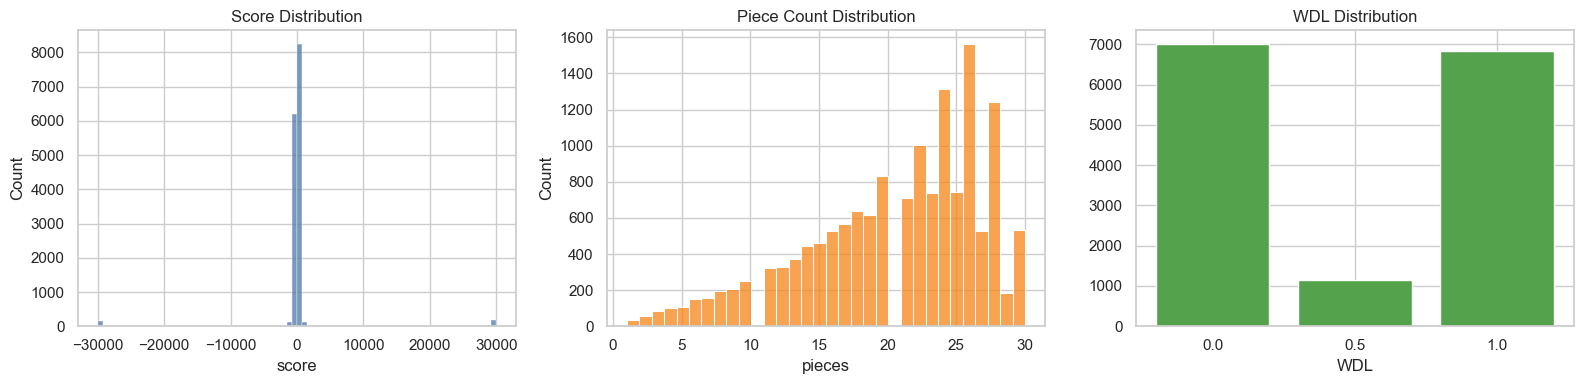

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(sample['score'], bins=80, ax=axes[0], color='#4C78A8')
axes[0].set_title('Score Distribution')
sns.histplot(sample['pieces'], bins=32, ax=axes[1], color='#F58518')
axes[1].set_title('Piece Count Distribution')
wdl_counts = sample['wdl'].value_counts().sort_index()
axes[2].bar([str(x) for x in wdl_counts.index], wdl_counts.values, color='#54A24B')
axes[2].set_title('WDL Distribution')
axes[2].set_xlabel('WDL')
plt.tight_layout()
plt.show()